In [324]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Baixar o dataset
path = kagglehub.dataset_download("gauravtopre/bank-customer-churn-dataset")

print("Path to dataset files:", path)

# Mostrar os arquivos presentes na pasta
print(os.listdir(path))


100%|██████████| 187k/187k [00:00<00:00, 437kB/s]

Extracting files...
Path to dataset files: C:\Users\italo\.cache\kagglehub\datasets\gauravtopre\bank-customer-churn-dataset\versions\1
['Bank Customer Churn Prediction.csv']


In [325]:
#Fazendo a leitura dos arquivos
df = pd.read_csv(os.path.join(path, "Bank Customer Churn Prediction.csv"))

print(df.head())

   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  


In [328]:
#analise geral

df = df.drop(columns=["customer_id"])

print("Dimensões do dataset:")
print(df.shape)

print("\nTipos das colunas:")
print(df.dtypes)

print("\nValores ausentes:")
print(df.isnull().sum())

print("\nDistribuição da variável alvo:")
print(df["churn"].value_counts(normalize=True)*100)


Dimensões do dataset:
(10000, 11)

Tipos das colunas:
credit_score          int64
country                 str
gender                  str
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

Valores ausentes:
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Distribuição da variável alvo:
churn
0    79.63
1    20.37
Name: proportion, dtype: float64


In [329]:
#variaveis categoricas
print("Países:")
print(df["country"].value_counts())

print("\nGêneros:")
print(df["gender"].value_counts())

Países:
country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gêneros:
gender
Male      5457
Female    4543
Name: count, dtype: int64


In [330]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df["churn"].value_counts())

churn
0    7963
1    2037
Name: count, dtype: int64


In [307]:
#tratamento de dados
X = heart_r.drop(columns=["Heart Disease Status"])
y = heart_r["Heart Disease Status"].map({"No": 0,"Yes": 1})

variaveis_numericas = [
    "Age",
    "Blood Pressure",
    "Cholesterol Level",
    "BMI",
    "Sleep Hours",
    "Triglyceride Level",
    "Fasting Blood Sugar",
    "CRP Level",
    "Homocysteine Level"]
variaveis_categoricas = [
    "Gender",
    "Exercise Habits",
    "Smoking",
    "Family Heart Disease",
    "Diabetes",
    "High Blood Pressure",
    "Low HDL Cholesterol",
    "High LDL Cholesterol",
    "Stress Level",
    "Sugar Consumption"]

variavel_alcool = ["Alcohol Consumption"]

In [308]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Dados de treinamento:", X_treino.shape)
print("Dados de teste:", X_teste.shape)

print(y.value_counts())
print("Valores ausentes no alvo:", y.isnull().sum())

Dados de treinamento: (3200, 20)
Dados de teste: (800, 20)
Heart Disease Status
0    2000
1    2000
Name: count, dtype: int64
Valores ausentes no alvo: 0


In [309]:
#Bibliotecas
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [310]:
tratamento_numerico = Pipeline([( "preencher_mediana",SimpleImputer(strategy="median"))])

tratamento_categorico = Pipeline([("preencher_frequente",SimpleImputer(strategy="most_frequent")),
    ("codificacao",OneHotEncoder(handle_unknown="ignore"))])

tratamento_alcool = Pipeline([("preencher_desconhecido",SimpleImputer(strategy="constant",fill_value="Unknown")),
    ("codificacao",OneHotEncoder(handle_unknown="ignore"))])

In [311]:
pre_processamento = ColumnTransformer([
    ("numericas",tratamento_numerico,variaveis_numericas),
    ("categoricas",tratamento_categorico,variaveis_categoricas),
    ("alcool",tratamento_alcool,variavel_alcool)])

In [312]:
from sklearn.ensemble import RandomForestClassifier
modelo_random_forest=Pipeline([("pre_processamento",pre_processamento),("modelo",
 RandomForestClassifier(n_estimators=500,
                           max_depth=None,
                           min_samples_split=2,
                           min_samples_leaf=1,
                           class_weight="balanced_subsample",
                           n_jobs=-1,
                           random_state=42))])


In [313]:
modelo_random_forest.fit(X_treino, y_treino)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


As métricas mais importantes serão:

Recall: quantas pessoas com doença foram identificadas;

Precisão: quantas classificadas com doença realmente pertenciam à classe;

F1-score: equilíbrio entre precisão e recall;

AUC: capacidade de separar as duas classes;

Matriz de confusão: quantidade de erros em cada classe.

In [314]:
previsoes_rf = modelo_random_forest.predict(X_teste)

probabilidades_rf = modelo_random_forest.predict_proba(X_teste)[:, 1]

In [315]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,)

In [316]:
acuracia_rf= accuracy_score(y_teste, previsoes_rf)
precisao_rf=precision_score(y_teste, previsoes_rf, zero_division=0)
recall_rf=recall_score(y_teste, previsoes_rf, zero_division=0)
f1_rf=f1_score(y_teste, previsoes_rf, zero_division=0)
auc_rf=roc_auc_score(y_teste, previsoes_rf)

In [317]:
print("RESULTADOS DA RANDOM FOREST")
print(f"Acurácia: {acuracia_rf:.3f}")
print(f"Precisão: {precisao_rf:.3f}")
print(f"Recall: {recall_rf:.3f}")
print(f"F1-score: {f1_rf:.3f}")
print(f"AUC: {auc_rf:.3f}")

RESULTADOS DA RANDOM FOREST
Acurácia: 0.519
Precisão: 0.520
Recall: 0.485
F1-score: 0.502
AUC: 0.519


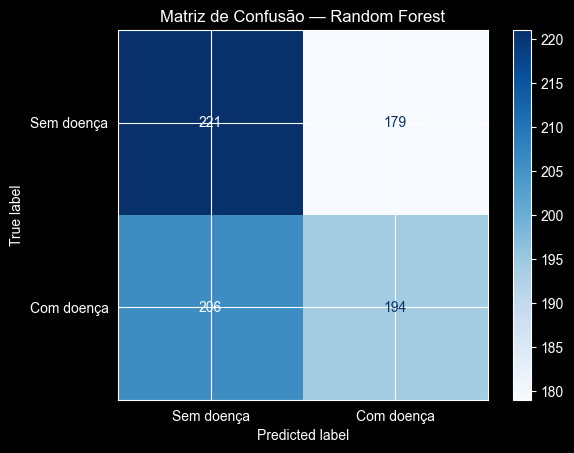

In [318]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_teste,
    previsoes_rf,
    display_labels=["Sem doença","Com doença"],cmap="Blues")

plt.title("Matriz de Confusão — Random Forest")
plt.show()